# Principal Component Analysis (PCA) from Scratch

## Objectives

- Understand the intuition behind PCA.
- Implement PCA using NumPy.
- Reduce high-dimensional data to fewer dimensions.
- Calculate explained variance.
- Visualize the transformed data.
- Compare the implementation with Scikit-Learn.

## PCA Intuition

Principal Component Analysis (PCA) is an unsupervised dimensionality
reduction technique.

PCA transforms the original features into a new set of uncorrelated
components called principal components.

The main idea is to:

1. Center the data.
2. Calculate the covariance matrix.
3. Find eigenvalues and eigenvectors.
4. Sort components by explained variance.
5. Project the data onto the selected components.

The first principal component captures the maximum possible variance.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
data = load_wine()

X = data.data
y = data.target

df = pd.DataFrame(
    X,
    columns=data.feature_names
)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (178, 13)
Scaled shape: (178, 13)


In [6]:
class PCAScratch:

    def __init__(self, n_components):
        self.n_components = n_components
        self.mean = None
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        X = np.asarray(X)

        # Center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # Covariance matrix
        covariance_matrix = np.cov(
            X_centered,
            rowvar=False
        )

        # Eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(
            covariance_matrix
        )

        # Sort from largest to smallest
        sorted_indices = np.argsort(
            eigenvalues
        )[::-1]

        eigenvalues = eigenvalues[sorted_indices]
        eigenvectors = eigenvectors[:, sorted_indices]

        # Explained variance
        total_variance = np.sum(eigenvalues)

        self.explained_variance_ = (
            eigenvalues[:self.n_components]
        )

        self.explained_variance_ratio_ = (
            self.explained_variance_
            / total_variance
        )

        # Shape: (n_features, n_components)
        self.components_ = (
            eigenvectors[:, :self.n_components]
        )

        return self

    def transform(self, X):
        X = np.asarray(X)

        X_centered = X - self.mean

        return X_centered @ self.components_

    def fit_transform(self, X):
        self.fit(X)

        return self.transform(X)

In [7]:
pca = PCAScratch(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

Original shape: (178, 13)
Reduced shape: (178, 2)

Explained variance ratio:
[0.36198848 0.1920749 ]


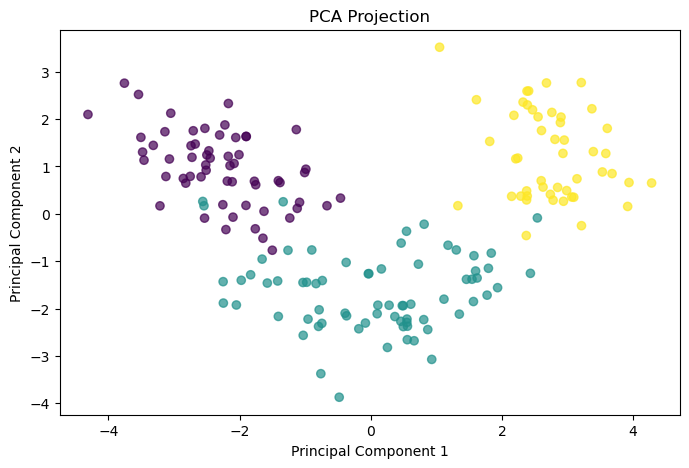

In [8]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")

plt.show()

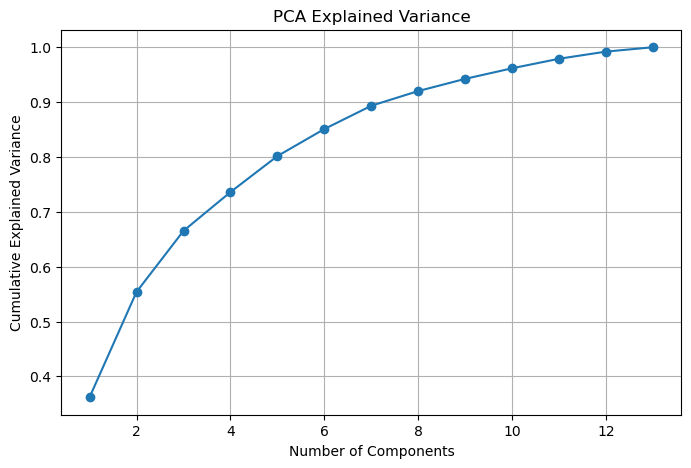

In [9]:
pca_full = PCAScratch(
    n_components=X_scaled.shape[1]
)

pca_full.fit(X_scaled)

explained_variance = (
    pca_full.explained_variance_ratio_
)

cumulative_variance = np.cumsum(
    explained_variance
)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

In [10]:
variance_table = pd.DataFrame({
    "Component": np.arange(
        1,
        len(explained_variance) + 1
    ),
    "Explained Variance": explained_variance,
    "Cumulative Variance": cumulative_variance
})

variance_table.head(10)

,Component,Explained Variance,Cumulative Variance
0,1,0.361988,0.361988
1,2,0.192075,0.554063
2,3,0.111236,0.665300
3,4,0.070690,0.735990
4,5,0.065633,0.801623
5,6,0.049358,0.850981
6,7,0.042387,0.893368
7,8,0.026807,0.920175
8,9,0.022222,0.942397
9,10,0.019300,0.961697


In [11]:
sklearn_pca = PCA(
    n_components=2
)

X_sklearn = sklearn_pca.fit_transform(
    X_scaled
)

comparison = pd.DataFrame({
    "Component": [
        "PC1",
        "PC2"
    ],
    "From Scratch": [
        pca.explained_variance_ratio_[0],
        pca.explained_variance_ratio_[1]
    ],
    "Scikit-Learn": [
        sklearn_pca.explained_variance_ratio_[0],
        sklearn_pca.explained_variance_ratio_[1]
    ]
})

comparison

,Component,From Scratch,Scikit-Learn
0,PC1,0.361988,0.361988
1,PC2,0.192075,0.192075


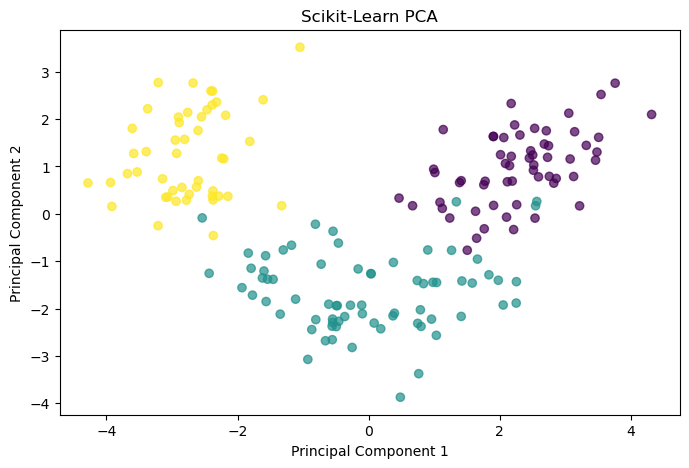

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_sklearn[:, 0],
    X_sklearn[:, 1],
    c=y,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Scikit-Learn PCA")

plt.show()

## Conclusion

- PCA reduces dimensionality while preserving as much variance as possible.
- PCA creates new features called principal components.
- Components are ordered according to the amount of variance they explain.
- Standardization is important when original features have different scales.
- PCA can help with visualization, preprocessing, and computational efficiency.
- The from-scratch implementation produces explained variance results
  comparable to Scikit-Learn.

## Limitations

- PCA is a linear dimensionality-reduction technique.
- Principal components can be difficult to interpret.
- PCA may lose information when too few components are selected.
- Results depend on feature scaling.